## End of W1D5 and Week 2 of Climate Match - W2D1 <br><br> Future Projections from ESMs in CMIP6 <br>

In [1]:
#!pip install cmocean
#!pip install gsw

#!pip install --upgrade --force-reinstall  pythia_datasets cartopy matplotlib geoviews xarray cftime nc-time-axis
#!pip install --no-binary shapely shapely --force

In [110]:
# imports
import time

tic = time.time()

import intake
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import xesmf as xe

from xmip.preprocessing import combined_preprocessing
from xarrayutils.plotting import shaded_line_plot

from datatree import DataTree
from xmip.postprocessing import _parse_metric

import cartopy.crs as ccrs

# were we missing these?
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt
from pythia_datasets import DATASETS
import cftime
import nc_time_axis

#!pip install cmocean
#!pip install gsw
import seaborn as sns
import cartopy as cart
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cmocean
import pooch
import os
import tempfile
import gsw

from scipy import integrate
from scipy import stats

from datetime import timedelta

# note, I had to do a conda install pythia-datasets to get this to work
#from pythia_datasets import DATASETS

#!pip install --upgrade --force-reinstall  pythia_datasets cartopy matplotlib geoviews xarray cftime nc-time-axis
#!pip install --no-binary shapely shapely --force
# some new imports
import cartopy.io.shapereader as shapereader
import matplotlib.dates as mdates
import geoviews as gv
import geoviews.feature as gf


import holoviews
from geoviews import Dataset as gvDataset
from geoviews import Image as gvImage

### Use monthly SST from a CMIP6 model (Taiwan ESM v1) and experiment for ssp585 <br><br> 
#### looks to be 2015 - 2100

In [3]:
# open an intake catalog containing the Pangeo CMIP cloud data
col = intake.open_esm_datastore(
    "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
)

# from the full `col` object, create a subset using facet search
cat = col.search(
    source_id="TaiESM1",
    variable_id="tos",
    member_id="r1i1p1f1",
    table_id="Omon",
    grid_label="gn",
    experiment_id="ssp585",
    require_all_on=[
        "source_id"
    ],  # make sure that we only get models which have all of the above experiments
)

# convert the sub-catalog into a datatree object, by opening each dataset into an xarray.Dataset (without loading the data)
kwargs = dict(
    preprocess=combined_preprocessing,  # apply xMIP fixes to each dataset
    xarray_open_kwargs=dict(
        use_cftime=True
    ),  # ensure all datasets use the same time index
    storage_options={
        "token": "anon"
    },  # anonymous/public authentication to google cloud storage
)

cat.esmcat.aggregation_control.groupby_attrs = ["source_id", "experiment_id"]
dt = cat.to_datatree(**kwargs)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_id/experiment_id'


In [4]:
dt

DataTree('None', parent=None)
└── DataTree('TaiESM1')
    └── DataTree('ssp585')
            Dimensions:         (member_id: 1, dcpp_init_year: 1, time: 1032, y: 384,
                                 x: 320, vertex: 4, bnds: 2)
            Coordinates:
                lat             (y, x) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
                lon             (y, x) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
              * time            (time) object 8kB 2015-01-17 00:29:59.999993 ... 2100-12-...
                lat_verticies   (y, x, vertex) float64 4MB dask.array<chunksize=(384, 320, 4), meta=np.ndarray>
                lon_verticies   (y, x, vertex) float64 4MB dask.array<chunksize=(384, 320, 4), meta=np.ndarray>
                time_bounds     (time, bnds) object 17kB dask.array<chunksize=(1032, 2), meta=np.ndarray>
              * y               (y) int64 3kB 0 1 2 3 4 5 6 ... 377 378 379 380 381 382 383
              * x               (x) int64 3kB 0 1 2 3 4 5 6 ... 313 314 315 316 317 318 319
                lon_bounds      (bnds, y, x) float64 2MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
                lat_bounds      (bnds, y, x) float64 2MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
              * member_id       (member_id) object 8B 'r1i1p1f1'
              * dcpp_init_year  (dcpp_init_year) float64 8B nan
            Dimensions without coordinates: vertex, bnds
            Data variables:
                tos             (member_id, dcpp_init_year, time, y, x) float32 507MB dask.array<chunksize=(1, 1, 87, 384, 320), meta=np.ndarray>
            Attributes: (12/62)
                Conventions:                      CF-1.7 CMIP-6.2
                activity_id:                      ScenarioMIP
                branch_method:                    Hybrid-restart from year 2015-01-01 of ...
                branch_time_in_child:             0.0
                branch_time_in_parent:            60225.0
                cmor_version:                     3.5.0
                ...                               ...
                intake_esm_attrs:variable_id:     tos
                intake_esm_attrs:grid_label:      gn
                intake_esm_attrs:zstore:          gs://cmip6/CMIP6/ScenarioMIP/AS-RCEC/Ta...
                intake_esm_attrs:version:         20210416
                intake_esm_attrs:_data_format_:   zarr
                intake_esm_dataset_key:           TaiESM1/ssp585

### *Note that CMIP6 experiments were run several years ago, so the cut-off between past (observed forcing) and future (scenario-based/projected forcing) was at the start of 2015. This means that July 2023 is about 8 years into the CMIP6 future and so it is unlikely to look exactly like Earth’s current SST state.*

In [5]:
dt.TaiESM1.ssp585.ds.tos

<xarray.DataArray 'tos' (member_id: 1, dcpp_init_year: 1, time: 1032, y: 384,
                         x: 320)> Size: 507MB
dask.array<broadcast_to, shape=(1, 1, 1032, 384, 320), dtype=float32, chunksize=(1, 1, 87, 384, 320), chunktype=numpy.ndarray>
Coordinates:
    lat             (y, x) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    lon             (y, x) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
  * time            (time) object 8kB 2015-01-17 00:29:59.999993 ... 2100-12-...
  * y               (y) int64 3kB 0 1 2 3 4 5 6 ... 377 378 379 380 381 382 383
  * x               (x) int64 3kB 0 1 2 3 4 5 6 ... 313 314 315 316 317 318 319
  * member_id       (member_id) object 8B 'r1i1p1f1'
  * dcpp_init_year  (dcpp_init_year) float64 8B nan
Attributes:
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Temperature of upper boundary of the liquid ocean, includ...
    history:        2021-04-16T01:30:38Z altered by CMOR: replaced missing va...
    long_name:      Sea Surface Temperature
    original_name:  TEMP
    standard_name:  sea_surface_temperature
    units:          °C

### Plot some stuff

In [8]:
%matplotlib inline

Text(0.5, 1.0, 'July 2023')

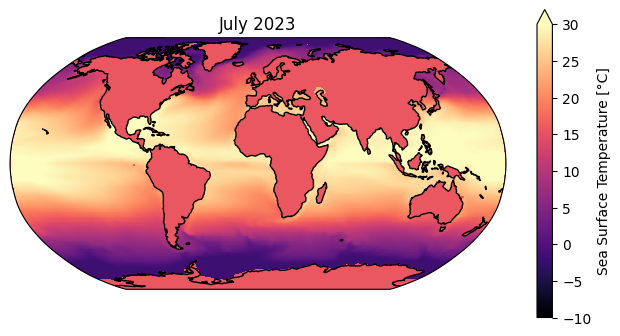

In [12]:
# select just a single model (TaiESM1) and experiment (ssp585) to plot
#sst_ssp585 = dt['TaiESM1/ssp585'].ds.tos
#sst_ssp585
sst_ssp585 = dt["TaiESM1"]["ssp585"].ds.tos

fig, (ax_present) = plt.subplots(
    ncols=1, nrows=1, figsize=[8, 4], subplot_kw={"projection": ccrs.Robinson()}
)

# select the model data for July 2023
sst_present = sst_ssp585.sel(time="2023-07").squeeze()

# plot the model data
sst_present.plot(
    ax=ax_present,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    vmin=-10,
    vmax=30,
    cmap="magma",
    robust=True,
)
ax_present.coastlines()
ax_present.set_title("July 2023")

Text(0.5, 1.0, 'July 2023')

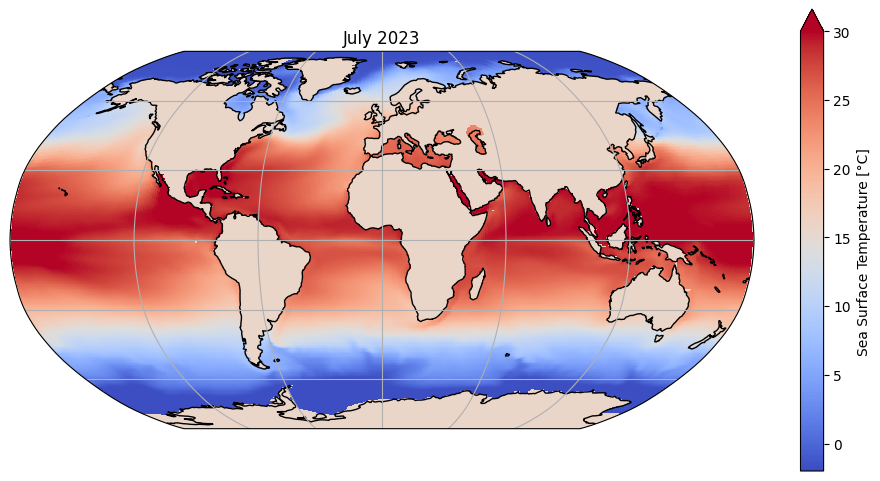

In [15]:
# plot first time entry
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson()) #central_longitude=180))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

# plot July 2023 SSTs
sst_present = sst_ssp585.sel(time="2023-07").squeeze()
sst_present.plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    vmin=-2,
    vmax=30,
    cmap="coolwarm"
)

ax.set_title("July 2023")


In [17]:
#sst_present.plot()

### Problems
1. Create a map of the projected sea surface temperature in July 2100 under the SSP5-8.5 high-emissions scenario (we’ll discuss scenarios in the next mini-lecture) using data from the TaiESM1 CMIP6 model. <br>

2. Create a map showing how this sea surface temperature projection is different from the current (July 2023) sea surface temperature in this model

3. Plot a similar map for this model that shows how January 2100 is different from January 2023



Text(0.5, 1.0, '2100 vs. 2023 Difference (January)')

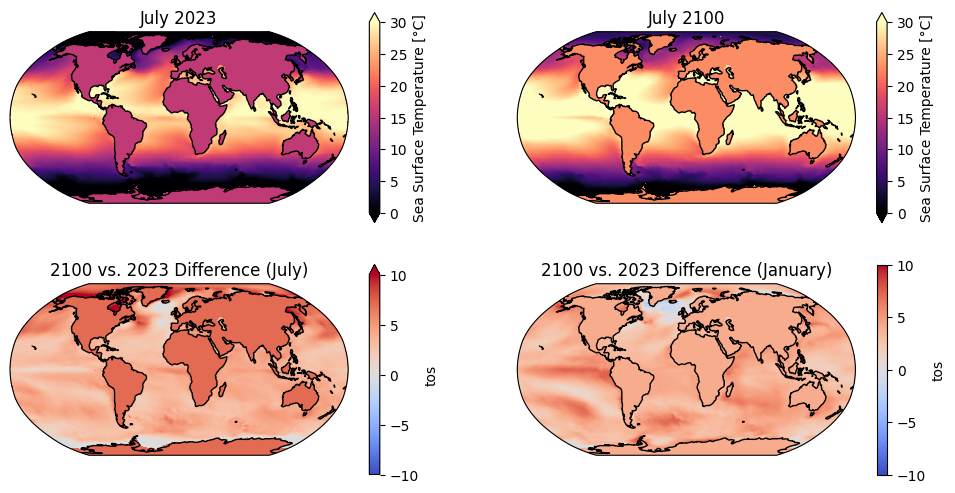

In [20]:
# select just a single model and experiment
sst_ssp585 = dt["TaiESM1"]["ssp585"].ds.tos

# crafty way to set up subplots I guess
fig, ([ax_present, ax_future], [ax_diff_july, ax_diff_jan]) = plt.subplots(
    ncols=2, nrows=2, figsize=[12, 6], subplot_kw={"projection": ccrs.Robinson()}
)

# plot a timestep for 2023
sst_present = sst_ssp585.sel(time="2023-07").squeeze()
sst_present.plot(
    ax=ax_present,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=30,
    cmap="magma",
    robust=True,
)
ax_present.coastlines()
ax_present.set_title("July 2023")

# repeat for 2100
# complete the following line to extract data for July 2100
sst_future = sst_ssp585.sel(time="2100-07").squeeze()
_ = sst_future.plot(
    ax=ax_future,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=30,
    cmap="magma",
    robust=True,
)
ax_future.coastlines()
ax_future.set_title("July 2100")

# now find the difference between July 2100 and July 2023
# complete the following line to extract the July difference
sst_difference_july = sst_future - sst_present
_ = sst_difference_july.plot(
    ax=ax_diff_july,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    vmin=-10,
    vmax=10,
    cmap="coolwarm",
    robust=True,
)
ax_diff_july.coastlines()
ax_diff_july.set_title("2100 vs. 2023 Difference (July)")

# finally, find the difference between January of the two years used above
# complete the following line to extract the January difference
sst_difference_jan = sst_ssp585.sel(time="2100-01").squeeze() - sst_ssp585.sel(time="2023-01").squeeze()
_ = sst_difference_jan.plot(
    ax=ax_diff_jan,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    vmin=-10,
    vmax=10,
    cmap="coolwarm",
    robust=True,
)
ax_diff_jan.coastlines()
ax_diff_jan.set_title("2100 vs. 2023 Difference (January)")

### in 2100 the N hemisphere is projected to get much warmer overall and the midlatitudes will get warmer too. Only a small change to the southern hemisphere

### <br> Irregular grids in ESMs <br>

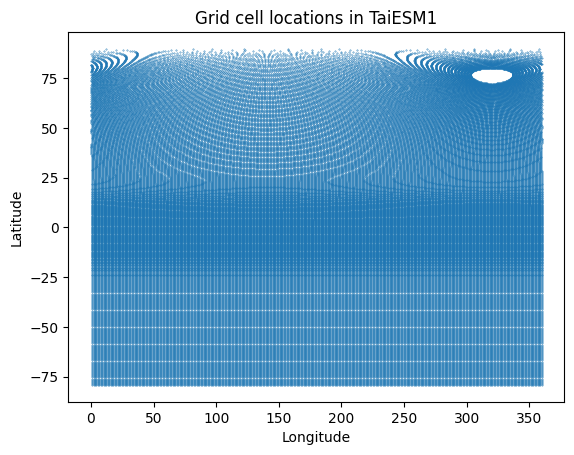

In [21]:
# create a scatter plot with a symbol at the center of each ocean grid cell in TaiESM1
fig, ax = plt.subplots()
ax.scatter(x=sst_ssp585.lon, y=sst_ssp585.lat, s=0.1)
ax.set_ylabel("Latitude")
ax.set_xlabel("Longitude")
ax.set_title("Grid cell locations in TaiESM1");

### wild grid spacing! 

### Re-gridding to a regular grid <br> Create a target grid to interpolate to

In [22]:
# define a 'target' grid. This is simply a regular lon/lat grid that we will interpolate our data on
ds_target = xr.Dataset(
    {
        "lat": (["lat"], np.arange(-90, 90, 1.0), {"units": "degrees_north"}),
        "lon": (["lon"], np.arange(0, 360, 1.0), {"units": "degrees_east"}),
    }
)  # you can try to modify the parameters above to e.g. just regrid onto a region or make the resolution coarser etc
ds_target

<xarray.Dataset> Size: 4kB
Dimensions:  (lat: 180, lon: 360)
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Data variables:
    *empty*

In [23]:
# define the regridder object (from our source dataarray to the target)
regridder = xe.Regridder(
    sst_ssp585, ds_target, "bilinear", periodic=True
)  # this takes some time to calculate a weight matrix for the regridding
regridder

xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_384x320_180x360_peri.nc 
Reuse pre-computed weights? False 
Input grid shape:           (384, 320) 
Output grid shape:          (180, 360) 
Periodic in longitude?      True

In [24]:
# now we can apply the regridder to our data
sst_ssp585_regridded = regridder(sst_ssp585)  # this is a lazy operation!
# so it does not slow us down significantly to apply it to the full data!
# we can work with this array just like before and the regridding will only be
# applied to the parts that we later load into memory or plot.
sst_ssp585_regridded

<xarray.DataArray (member_id: 1, dcpp_init_year: 1, time: 1032, lat: 180,
                   lon: 360)> Size: 267MB
dask.array<astype, shape=(1, 1, 1032, 180, 360), dtype=float32, chunksize=(1, 1, 87, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * time            (time) object 8kB 2015-01-17 00:29:59.999993 ... 2100-12-...
  * member_id       (member_id) object 8B 'r1i1p1f1'
  * dcpp_init_year  (dcpp_init_year) float64 8B nan
  * lat             (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0
  * lon             (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
Attributes:
    regrid_method:  bilinear

In [25]:
sst_ssp585

<xarray.DataArray 'tos' (member_id: 1, dcpp_init_year: 1, time: 1032, y: 384,
                         x: 320)> Size: 507MB
dask.array<broadcast_to, shape=(1, 1, 1032, 384, 320), dtype=float32, chunksize=(1, 1, 87, 384, 320), chunktype=numpy.ndarray>
Coordinates:
    lat             (y, x) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    lon             (y, x) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
  * time            (time) object 8kB 2015-01-17 00:29:59.999993 ... 2100-12-...
  * y               (y) int64 3kB 0 1 2 3 4 5 6 ... 377 378 379 380 381 382 383
  * x               (x) int64 3kB 0 1 2 3 4 5 6 ... 313 314 315 316 317 318 319
  * member_id       (member_id) object 8B 'r1i1p1f1'
  * dcpp_init_year  (dcpp_init_year) float64 8B nan
Attributes:
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Temperature of upper boundary of the liquid ocean, includ...
    history:        2021-04-16T01:30:38Z altered by CMOR: replaced missing va...
    long_name:      Sea Surface Temperature
    original_name:  TEMP
    standard_name:  sea_surface_temperature
    units:          °C

### Let’s use the code from above to plot a map of the model data on its original (native) grid, and a map of the model data after it is regridded.

Text(0.5, 1.0, 'July 2100 Regridded')

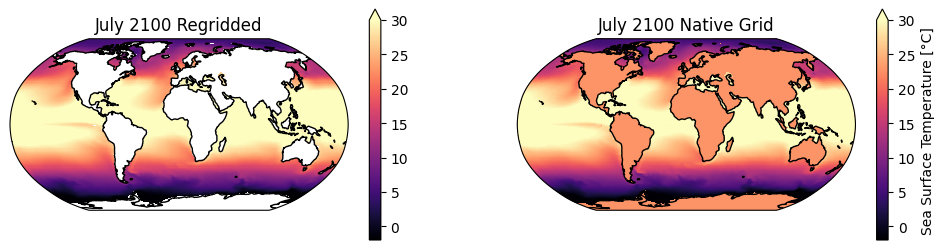

In [26]:
fig, ([ax_regridded, ax_native]) = plt.subplots(
    ncols=2, figsize=[12, 3], subplot_kw={"projection": ccrs.Robinson()}
)

# Native grid data
sst_future = sst_ssp585.sel(time="2100-07").squeeze()
sst_future.plot(
    ax=ax_native,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    vmin=-2,
    vmax=30,
    cmap="magma",
    robust=True,
)
ax_native.coastlines()
ax_native.set_title("July 2100 Native Grid")

# Regridded data
sst_future_regridded = sst_ssp585_regridded.sel(time="2100-07").squeeze()
sst_future_regridded.plot(
    ax=ax_regridded,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    vmin=-2,
    vmax=30,
    cmap="magma",
    robust=True,
)
ax_regridded.coastlines()
ax_regridded.set_title("July 2100 Regridded")

### Helpful page with examples for working with CMIP6 data from PANGEO https://gallery.pangeo.io/repos/pangeo-gallery/cmip6/index.html

## <br> Tutorial 8: Time series, global averages, scenario comparisons from multiple SSP experiments in CMIP6 <br><br>

### using data from three experiments

- historical: a simulation of 1850-2015 using observed forcing,

- SSP1-2.6: a future, low-emissions scenario, and

- SSP5-8.5: a future, high-emissions scenario.

In [27]:
# open an intake catalog containing the Pangeo CMIP cloud data
col = intake.open_esm_datastore(
    "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
)

# pick the experiments you require
experiment_ids = ["historical", "ssp126", "ssp585"]

# from the full `col` object, create a subset using facet search
cat = col.search(
    source_id="TaiESM1",
    variable_id="tos",
    member_id="r1i1p1f1",
    table_id="Omon",
    grid_label="gn",
    experiment_id=experiment_ids,
    require_all_on=[
        "source_id"
    ],  # make sure that we only get models which have all of the above experiments
)

# convert the sub-catalog into a datatree object, by opening each dataset into an xarray.Dataset (without loading the data)
kwargs = dict(
    preprocess=combined_preprocessing,  # apply xMIP fixes to each dataset
    xarray_open_kwargs=dict(
        use_cftime=True
    ),  # ensure all datasets use the same time index
    storage_options={
        "token": "anon"
    },  # anonymous/public authentication to google cloud storage
)
# construct sub-catalog datatree with attributes
cat.esmcat.aggregation_control.groupby_attrs = ["source_id", "experiment_id"]
dt = cat.to_datatree(**kwargs)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_id/experiment_id'


In [28]:
dt

DataTree('None', parent=None)
└── DataTree('TaiESM1')
    ├── DataTree('ssp585')
    │       Dimensions:         (member_id: 1, dcpp_init_year: 1, time: 1032, y: 384,
    │                            x: 320, vertex: 4, bnds: 2)
    │       Coordinates:
    │           lat             (y, x) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    │           lon             (y, x) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    │         * time            (time) object 8kB 2015-01-17 00:29:59.999993 ... 2100-12-...
    │           lat_verticies   (y, x, vertex) float64 4MB dask.array<chunksize=(384, 320, 4), meta=np.ndarray>
    │           lon_verticies   (y, x, vertex) float64 4MB dask.array<chunksize=(384, 320, 4), meta=np.ndarray>
    │           time_bounds     (time, bnds) object 17kB dask.array<chunksize=(1032, 2), meta=np.ndarray>
    │         * y               (y) int64 3kB 0 1 2 3 4 5 6 ... 377 378 379 380 381 382 383
    │         * x               (x) int64 3kB 0 1 2 3 4 5 6 ... 313 314 315 316 317 318 319
    │           lon_bounds      (bnds, y, x) float64 2MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    │           lat_bounds      (bnds, y, x) float64 2MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    │         * member_id       (member_id) object 8B 'r1i1p1f1'
    │         * dcpp_init_year  (dcpp_init_year) float64 8B nan
    │       Dimensions without coordinates: vertex, bnds
    │       Data variables:
    │           tos             (member_id, dcpp_init_year, time, y, x) float32 507MB dask.array<chunksize=(1, 1, 87, 384, 320), meta=np.ndarray>
    │       Attributes: (12/62)
    │           Conventions:                      CF-1.7 CMIP-6.2
    │           activity_id:                      ScenarioMIP
    │           branch_method:                    Hybrid-restart from year 2015-01-01 of ...
    │           branch_time_in_child:             0.0
    │           branch_time_in_parent:            60225.0
    │           cmor_version:                     3.5.0
    │           ...                               ...
    │           intake_esm_attrs:variable_id:     tos
    │           intake_esm_attrs:grid_label:      gn
    │           intake_esm_attrs:zstore:          gs://cmip6/CMIP6/ScenarioMIP/AS-RCEC/Ta...
    │           intake_esm_attrs:version:         20210416
    │           intake_esm_attrs:_data_format_:   zarr
    │           intake_esm_dataset_key:           TaiESM1/ssp585
    ├── DataTree('historical')
    │       Dimensions:         (member_id: 1, dcpp_init_year: 1, time: 1980, y: 384,
    │                            x: 320, vertex: 4, bnds: 2)
    │       Coordinates:
    │           lat             (y, x) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    │           lon             (y, x) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    │         * time            (time) object 16kB 1850-01-17 00:30:00 ... 2014-12-16 12:...
    │           lat_verticies   (y, x, vertex) float64 4MB dask.array<chunksize=(384, 320, 4), meta=np.ndarray>
    │           lon_verticies   (y, x, vertex) float64 4MB dask.array<chunksize=(384, 320, 4), meta=np.ndarray>
    │           time_bounds     (time, bnds) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
    │         * y               (y) int64 3kB 0 1 2 3 4 5 6 ... 377 378 379 380 381 382 383
    │         * x               (x) int64 3kB 0 1 2 3 4 5 6 ... 313 314 315 316 317 318 319
    │           lon_bounds      (bnds, y, x) float64 2MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    │           lat_bounds      (bnds, y, x) float64 2MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    │         * member_id       (member_id) object 8B 'r1i1p1f1'
    │         * dcpp_init_year  (dcpp_init_year) float64 8B nan
    │       Dimensions without coordinates: vertex, bnds
    │       Data variables:
    │           tos             (member_id, dcpp_i

Write code to load this ocean-grid area data using the previously shown method for SST data, noting that:

- We now need a variable called areacello (area of cells in the ocean)

- This variable is stored in table_id Ofx (it is from the ocean model and is fixed/constant in time)

- A model’s grid does not change between experiments so you only need to get grid data from the historical experiment for each model

In [38]:
cat_area = col.search(
    source_id = "TaiESM1",
    # Add the appropriate variable_id
    variable_id = "areacello",
    member_id = "r1i1p1f1",
    # Add the appropriate table_id
    table_id = "Ofx",
    grid_label = "gn",
    # Add the appropriate experiment_id
    experiment_id = ["historical"],
    require_all_on = ["source_id"],
)
# construct sub-catalog datatree with attributes
cat_area.esmcat.aggregation_control.groupby_attrs = ["source_id", "experiment_id"]
dt_area = cat_area.to_datatree(**kwargs)

# instantiate a DataTree object
dt_with_area = DataTree()

# add the sub-catalog to the DataTree object via map_over_subtree()
for model, subtree in dt.items():
    metric = dt_area[model]["historical"].ds["areacello"]
    dt_with_area[model] = subtree.map_over_subtree(_parse_metric, metric)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_id/experiment_id'


In [39]:
dt_with_area

DataTree('None', parent=None)
└── DataTree('TaiESM1')
    ├── DataTree('ssp585')
    │       Dimensions:         (member_id: 1, dcpp_init_year: 1, time: 1032, y: 384,
    │                            x: 320, vertex: 4, bnds: 2)
    │       Coordinates: (12/13)
    │           lat             (y, x) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    │           lon             (y, x) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    │         * time            (time) object 8kB 2015-01-17 00:29:59.999993 ... 2100-12-...
    │           lat_verticies   (y, x, vertex) float64 4MB dask.array<chunksize=(384, 320, 4), meta=np.ndarray>
    │           lon_verticies   (y, x, vertex) float64 4MB dask.array<chunksize=(384, 320, 4), meta=np.ndarray>
    │           time_bounds     (time, bnds) object 17kB dask.array<chunksize=(1032, 2), meta=np.ndarray>
    │           ...              ...
    │         * x               (x) int64 3kB 0 1 2 3 4 5 6 ... 313 314 315 316 317 318 319
    │           lon_bounds      (bnds, y, x) float64 2MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    │           lat_bounds      (bnds, y, x) float64 2MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    │         * member_id       (member_id) object 8B 'r1i1p1f1'
    │         * dcpp_init_year  (dcpp_init_year) float64 8B nan
    │           areacello       (member_id, dcpp_init_year, y, x) float32 492kB dask.array<chunksize=(1, 1, 384, 320), meta=np.ndarray>
    │       Dimensions without coordinates: vertex, bnds
    │       Data variables:
    │           tos             (member_id, dcpp_init_year, time, y, x) float32 507MB dask.array<chunksize=(1, 1, 87, 384, 320), meta=np.ndarray>
    │       Attributes: (12/62)
    │           Conventions:                      CF-1.7 CMIP-6.2
    │           activity_id:                      ScenarioMIP
    │           branch_method:                    Hybrid-restart from year 2015-01-01 of ...
    │           branch_time_in_child:             0.0
    │           branch_time_in_parent:            60225.0
    │           cmor_version:                     3.5.0
    │           ...                               ...
    │           intake_esm_attrs:variable_id:     tos
    │           intake_esm_attrs:grid_label:      gn
    │           intake_esm_attrs:zstore:          gs://cmip6/CMIP6/ScenarioMIP/AS-RCEC/Ta...
    │           intake_esm_attrs:version:         20210416
    │           intake_esm_attrs:_data_format_:   zarr
    │           intake_esm_dataset_key:           TaiESM1/ssp585
    ├── DataTree('historical')
    │       Dimensions:         (member_id: 1, dcpp_init_year: 1, time: 1980, y: 384,
    │                            x: 320, vertex: 4, bnds: 2)
    │       Coordinates: (12/13)
    │           lat             (y, x) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    │           lon             (y, x) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    │         * time            (time) object 16kB 1850-01-17 00:30:00 ... 2014-12-16 12:...
    │           lat_verticies   (y, x, vertex) float64 4MB dask.array<chunksize=(384, 320, 4), meta=np.ndarray>
    │           lon_verticies   (y, x, vertex) float64 4MB dask.array<chunksize=(384, 320, 4), meta=np.ndarray>
    │           time_bounds     (time, bnds) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
    │           ...              ...
    │         * x               (x) int64 3kB 0 1 2 3 4 5 6 ... 313 314 315 316 317 318 319
    │           lon_bounds      (bnds, y, x) float64 2MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    │           lat_bounds      (bnds, y, x) float64 2MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    │         * member_id       (member_id) object 8B 'r1i1p1f1'
    │         * dcpp_init_year  (dcpp_init_year) float64 8B nan
    │           areacello       (member_id, dcpp_init_year, y, x) float32 492kB dask.array<ch

In [40]:
def global_mean(ds: xr.Dataset):# -> xr.Dataset:
    """Global average, weighted by the cell area"""
    return ds.weighted(ds.areacello.fillna(0)).mean(["x", "y"], keep_attrs=True)

# average every dataset in the tree globally via map_over_subtree() function introduced in Tutorial 7
dt_gm = dt_with_area.map_over_subtree(global_mean)

dt_gm.TaiESM1

DataTree('TaiESM1', parent="None")
├── DataTree('ssp585')
│       Dimensions:         (time: 1032, member_id: 1, dcpp_init_year: 1)
│       Coordinates:
│         * time            (time) object 8kB 2015-01-17 00:29:59.999993 ... 2100-12-...
│         * member_id       (member_id) object 8B 'r1i1p1f1'
│         * dcpp_init_year  (dcpp_init_year) float64 8B nan
│       Data variables:
│           tos             (member_id, dcpp_init_year, time) float32 4kB dask.array<chunksize=(1, 1, 87), meta=np.ndarray>
├── DataTree('historical')
│       Dimensions:         (time: 1980, member_id: 1, dcpp_init_year: 1)
│       Coordinates:
│         * time            (time) object 16kB 1850-01-17 00:30:00 ... 2014-12-16 12:...
│         * member_id       (member_id) object 8B 'r1i1p1f1'
│         * dcpp_init_year  (dcpp_init_year) float64 8B nan
│       Data variables:
│           tos             (member_id, dcpp_init_year, time) float32 8kB dask.array<chunksize=(1, 1, 87), meta=np.ndarray>
└── DataTree('ssp126')
        Dimensions:         (time: 1032, member_id: 1, dcpp_init_year: 1)
        Coordinates:
          * time            (time) object 8kB 2015-01-16 12:00:00 ... 2100-12-16 12:0...
          * member_id       (member_id) object 8B 'r1i1p1f1'
          * dcpp_init_year  (dcpp_init_year) float64 8B nan
        Data variables:
            tos             (member_id, dcpp_init_year, time) float32 4kB dask.array<chunksize=(1, 1, 87), meta=np.ndarray>

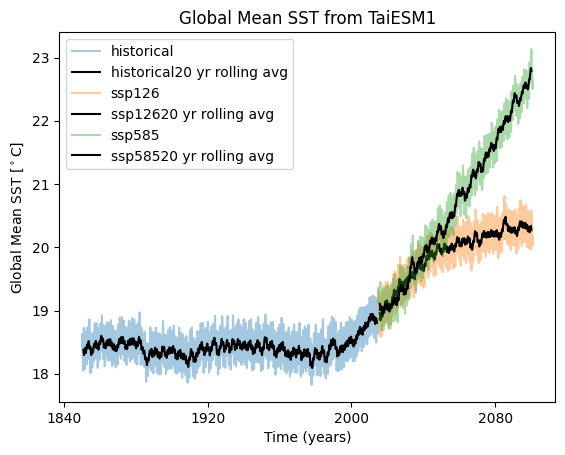

In [45]:
# create plot
fig, ax = plt.subplots()
for experiment in ["historical", "ssp126", "ssp585"]:
    # slice tos data array of experiment
    da = dt_gm['TaiESM1'][experiment].ds.tos
    droll = dt_gm['TaiESM1'][experiment].ds.tos.rolling(time=20, center=True).mean() # make a 5 yr rolling average
    # draw data
    _ = da.plot(label=experiment, ax=ax, alpha=0.4)
    _ = droll.plot(label = experiment + " 20 yr rolling avg", ax=ax, color="k")
ax.set_title("Global Mean SST from TaiESM1")
ax.set_ylabel("Global Mean SST [$^\circ$C]")
ax.set_xlabel("Time (years)")
ax.legend()


# t2m_3day_avg = ds_surface_temp_2m_ts.rolling(time=24*3, center=True).mean()

## <br> W2D1: IPCC Physical Basis Kinds of Projects <br><br> Tutorial 1: Internal Climate Variability and Single-model ensembles <br>

In [46]:
# no new imports but some helper functions needed

def readin_cmip6_to_datatree(facet_dict):
    # open an intake catalog containing the Pangeo CMIP cloud data
    col = intake.open_esm_datastore(
        "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
    )

    # from the full `col` object, create a subset using facet search
    cat = col.search(
        source_id=facet_dict['source_id'],
        variable_id=facet_dict['variable_id'],
        member_id=facet_dict['member_id'],
        table_id=facet_dict['table_id'],
        grid_label=facet_dict['grid_label'],
        experiment_id=facet_dict['experiment_id'],
        require_all_on=facet_dict['require_all_on']  # make sure that we only get models which have all of the above experiments
    )

    # convert the sub-catalog into a datatree object, by opening each dataset into an xarray.Dataset (without loading the data)
    kwargs = dict(
        preprocess=combined_preprocessing,  # apply xMIP fixes to each dataset
        xarray_open_kwargs=dict(
            use_cftime=True
        ),  # ensure all datasets use the same time index
        storage_options={
            "token": "anon"
        },  # anonymous/public authentication to google cloud storage
    )
    cat.esmcat.aggregation_control.groupby_attrs = ["source_id", "experiment_id"]
    dt = cat.to_datatree(**kwargs)
    return dt
    

def global_mean(ds: xr.Dataset) -> xr.Dataset:
    """Global average, weighted by the cell area"""
    return ds.weighted(ds.areacello.fillna(0)).mean(["x", "y"], keep_attrs=True)


# Calculate anomaly to reference period
def datatree_anomaly(dt):
    dt_out = DataTree()
    for model, subtree in dt.items():
        ref = dt[model]["historical"].ds.sel(time=slice("1950", "1980")).mean()
        dt_out[model] = subtree - ref
    return dt_out

### <br> Use helpers to load in MPI-ESM1-2-LR experiments (r1i1p1f1 through r5i1p1f1) <br><br>

In [47]:
# dictionary of facets for query of surface temperature data
facet_dict = { "source_id":"MPI-ESM1-2-LR",
    "variable_id":"tos",
    "member_id":["r1i1p1f1", "r2i1p1f1", "r3i1p1f1", "r4i1p1f1", "r5i1p1f1"],
    "table_id":"Omon",
    "grid_label":"gn",
    "experiment_id":"historical",
    "require_all_on":["source_id", "member_id"]
    }

# dictionary for query of cell area metric
facet_dict_area = { "source_id":"MPI-ESM1-2-LR",
    "variable_id":"areacello",
    "member_id":"r1i1p1f1",
    "table_id":"Ofx",
    "grid_label":"gn",
    "experiment_id":"historical",
    "require_all_on":"source_id"
    }

# search for temperature and area data and return datatree objects
dt_ensemble = readin_cmip6_to_datatree(facet_dict)
dt_area = readin_cmip6_to_datatree(facet_dict_area)


# add the area (we can reuse the area from before,
# since for a given model the horizontal area does not vary between members)
dt_ensemble_with_area = DataTree()
for model, subtree in dt_ensemble.items():
    metric = dt_area["MPI-ESM1-2-LR"]["historical"].ds["areacello"].squeeze()
    dt_ensemble_with_area[model] = subtree.map_over_subtree(_parse_metric, metric)

# global average
# average every dataset in the tree globally
dt_ensemble_gm = dt_ensemble_with_area.map_over_subtree(global_mean)

# calculate anomaly
dt_ensemble_gm_anomaly = datatree_anomaly(dt_ensemble_gm)

# coarsen data for plotting the historical values of the 5 members
dt_ensemble_gm_anomaly_hist = dt_ensemble_gm_anomaly['MPI-ESM1-2-LR']['historical'].ds.coarsen(time=12).mean().tos


--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_id/experiment_id'



--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_id/experiment_id'


### Plot the historical experiment data for each realization, using a distinct color for each realization.

In [53]:
#dt_ensemble_gm_anomaly_hist

Text(0.5, 0, 'Time (years)')

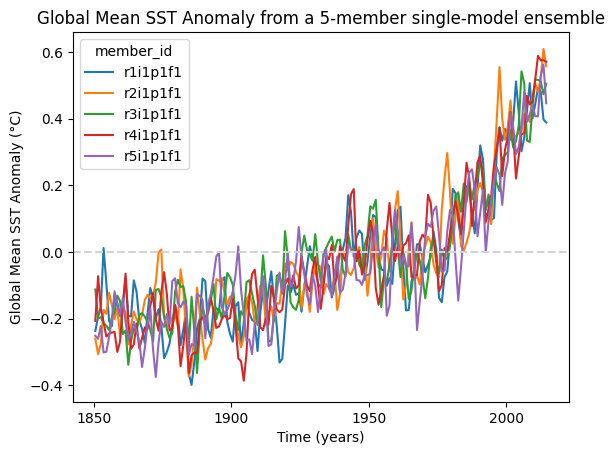

In [52]:
fig, ax = plt.subplots()

# plot the data dt_ensemble_gm_anomaly_hist with a different color for each member id
_ = dt_ensemble_gm_anomaly_hist.plot(hue = 'member_id')

ax.set_title(
    "Global Mean SST Anomaly from a 5-member single-model ensemble"
)

plt.axhline(0, linestyle='dashed', color='lightgrey')
ax.set_ylabel("Global Mean SST Anomaly (°C)")
ax.set_xlabel("Time (years)")


### Plot the mean SST anomaly of the single-model ensemble, with an envelope visualizing the spread across members (excluding the lowest and highest 17%)

In [55]:
# First calculate the tos/SST annual mean
da = (
    dt_ensemble_gm_anomaly["MPI-ESM1-2-LR"]['historical']
    .ds.tos.coarsen(time=12)
    .mean()
    .load()
)
#da

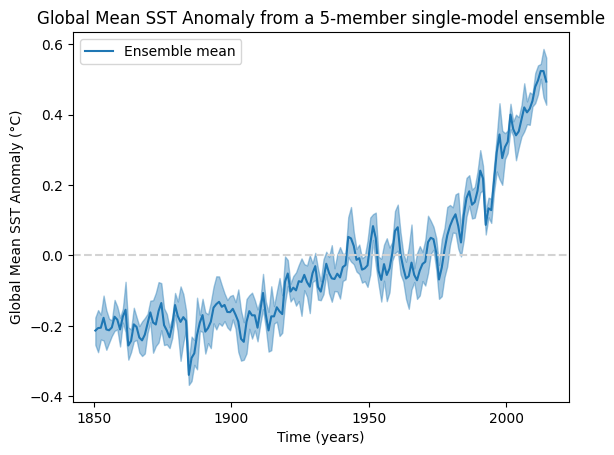

In [58]:
fig,ax = plt.subplots()

# get mean across all realizations and plot it
da_mean = da.mean("member_id")
da_mean.plot(color = "C0", label="Ensemble mean", ax=ax)

# now create pieces needed for the fill_between
x = da.time.data # x axis

# need the lowest 17% cut off to exclude it and same for upper 17%
da_lower = da.squeeze().quantile(0.17, dim="member_id")
da_upper = da.squeeze().quantile(0.83, dim="member_id")

_ = ax.fill_between(x, da_lower, da_upper, alpha = 0.4, color = "C0")

# aesthetics
plt.axhline(0, linestyle='dashed', color='lightgrey')
ax.set_title(
    "Global Mean SST Anomaly from a 5-member single-model ensemble"
)
ax.set_ylabel("Global Mean SST Anomaly (°C)")
ax.set_xlabel("Time (years)")
ax.legend()

### That's a very IPCC looking plot :) 

## <br> Tutorial 2: Future Climate & Multi-model ensembles <br><br>

#### In this tutorial, we will analyze data from five different CMIP6 models developed by various institutions around the world, focusing on their historical simulations and low-emission projections (SSP1-2.6). By the end of this tutorial, you will be able to

- Load CMIP6 Sea Surface Temperature (SST) data from multiple models;

- Calculate the SST anomalies, and recall the concept of temperature anomaly in relation to a base period

#### Now we will start to analyze a multi-model ensemble that consists of data from multiple CMIP6 models, and includes both historical simulations and future scenario projections.

- Your multi-model ensemble will consist of Five different CMIP6 models developed by institutions from a variety of countries:

- TaiESM1 (Research Center for Environmental Changes, Taiwan),

- IPSL-CM6A-LR (Institut Pierre Simon Laplace, France),

- GFDL-ESM4 (NOAA Geophysical Fluid Dynamics Laboratory, USA),

- ACCESS-CM2 (CSIRO and ARCCSS, Australia), and

- MPI-ESM1-2-LR (Max Planck Institute, Germany).

In [59]:
# @title Helper functions

def readin_cmip6_to_datatree(facet_dict):
    # open an intake catalog containing the Pangeo CMIP cloud data
    col = intake.open_esm_datastore(
        "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
    )

    # from the full `col` object, create a subset using facet search
    cat = col.search(
        source_id=facet_dict['source_id'],
        variable_id=facet_dict['variable_id'],
        member_id=facet_dict['member_id'],
        table_id=facet_dict['table_id'],
        grid_label=facet_dict['grid_label'],
        experiment_id=facet_dict['experiment_id'],
        require_all_on=facet_dict['require_all_on']  # make sure that we only get models which have all of the above experiments
    )

    # convert the sub-catalog into a datatree object, by opening each dataset into an xarray.Dataset (without loading the data)
    kwargs = dict(
        preprocess=combined_preprocessing,  # apply xMIP fixes to each dataset
        xarray_open_kwargs=dict(
            use_cftime=True
        ),  # ensure all datasets use the same time index
        storage_options={
            "token": "anon"
        },  # anonymous/public authentication to google cloud storage
    )

    cat.esmcat.aggregation_control.groupby_attrs = ["source_id", "experiment_id"]
    dt = cat.to_datatree(**kwargs)

    return dt


def global_mean(ds: xr.Dataset) -> xr.Dataset:
    """Global average, weighted by the cell area"""
    return ds.weighted(ds.areacello.fillna(0)).mean(["x", "y"], keep_attrs=True)

In [60]:
# selected CMIP6 models to explore
source_ids = ["IPSL-CM6A-LR", "GFDL-ESM4", "ACCESS-CM2", "MPI-ESM1-2-LR", "TaiESM1"]

# dictionary of facets for query of surface temperature data
facet_dict = { "source_id":source_ids,
    "variable_id":"tos",
    "member_id":"r1i1p1f1",
    "table_id":"Omon",
    "grid_label":"gn",
    "experiment_id":["historical", "ssp126", "ssp585"],
    "require_all_on":"source_id"
    }

# dictionary for query of cell area metric
facet_dict_area = { "source_id":source_ids,
    "variable_id":"areacello",
    "member_id":"r1i1p1f1",
    "table_id":"Ofx",
    "grid_label":"gn",
    "experiment_id":"historical",
    "require_all_on":"source_id"
    }

# search for temperature and area data and return datatree objects
dt = readin_cmip6_to_datatree(facet_dict)
dt_area = readin_cmip6_to_datatree(facet_dict_area)

# merge area metric into datatree object
dt_with_area = DataTree()
for model, subtree in dt.items():
    metric = dt_area[model]["historical"].ds["areacello"]
    dt_with_area[model] = subtree.map_over_subtree(_parse_metric, metric)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_id/experiment_id'



--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_id/experiment_id'


#### Coding Exercise 1.1: Combine past and future data, remove seasonal oscillations, and plot all 5 of the CMIP6 models we just loaded <br>

In [63]:
# can see the details on each model and experiments within the data tree
#dt.keys

In [68]:
# average every dataset in the tree globally
dt_gm = dt_with_area.map_over_subtree(global_mean)

# create plot
# this is the same plot as the previous tutorial so skipping
# fig, ax = plt.subplots()
# # draw every scenario
# for experiment in ["historical", "ssp126", "ssp585"]:
#     da = dt_gm["TaiESM1"][experiment].ds.tos
#     da.plot(label=experiment, ax=ax)

# # aesthetics
# ax.set_title("Global Mean SST from TaiESM1")
# ax.set_ylabel("Global Mean SST (°C)")
# ax.set_xlabel("Time (years)")
# ax.legend()

CPU times: user 48.6 s, sys: 20 s, total: 1min 8s
Wall time: 2min 24s


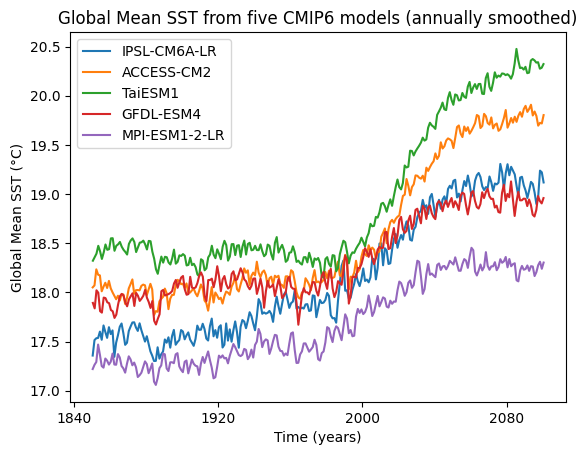

In [70]:
%%time
#################################################
## TODO for students: Plot annually smoothed global mean SST for all models##
#################################################

# function to make the plot for a set of models (all those in dt.keys)
def plot_historical_ssp126_combined(dt, ax):
    for model in dt.keys():
        datasets = []
        for experiment in ["historical", "ssp126"]:
            datasets.append(dt[model][experiment].tos)

        # for each of the models, concatenate its historical and future data
        da_combined = xr.concat(datasets, dim="time")
        # plot annual averages
        da_combined.coarsen(time=12).mean().plot(label=model, ax=ax)


fig, ax = plt.subplots()
# plot_historical_ssp126_combined
_ = plot_historical_ssp126_combined(dt_gm, ax)

ax.set_title("Global Mean SST from five CMIP6 models (annually smoothed)")
ax.set_ylabel("Global Mean SST (°C)")
ax.set_xlabel("Time (years)")
ax.legend()

#### Quite a lot of variability between the different models - likely due to different physics, discretezations, parameterizations, etc

#### recreate the previous multi-model figure, but now instead plot the global mean sea surface temperature (GMSST) anomaly relative to the 1950-1980 base period (i.e., subtract the 1950-1980 mean GMSST of each model from that model’s time series)

In [71]:
dt_gm['GFDL-ESM4']['historical'].ds

<xarray.DatasetView> Size: 24kB
Dimensions:         (time: 1980, member_id: 1, dcpp_init_year: 1)
Coordinates:
  * time            (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:...
  * member_id       (member_id) object 8B 'r1i1p1f1'
  * dcpp_init_year  (dcpp_init_year) float64 8B nan
Data variables:
    tos             (member_id, dcpp_init_year, time) float32 8kB dask.array<chunksize=(1, 1, 120), meta=np.ndarray>

CPU times: user 48.7 s, sys: 20.3 s, total: 1min 8s
Wall time: 2min 25s


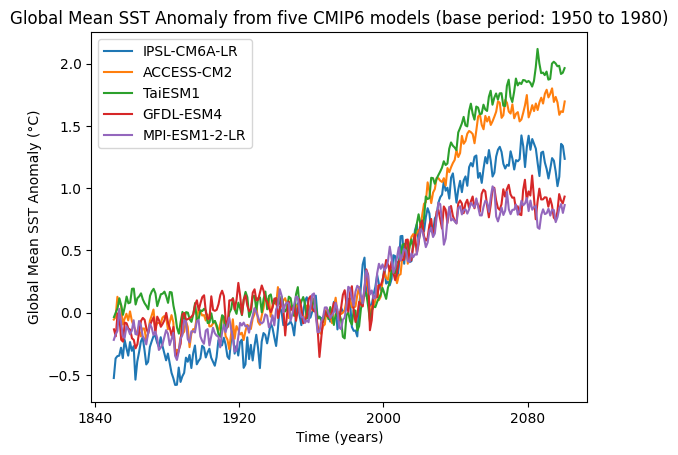

In [72]:
%%time
#################################################
## TODO for students: Plot global mean SST anomaly for all models.##
#################################################

# calculate anomaly to reference period
def datatree_anomaly(dt):
    dt_out = DataTree()
    for model, subtree in dt.items():
        # find the temporal average over the desired reference period
        ref = dt[model]["historical"].ds.sel(time = slice('1950','1980')).mean()
        dt_out[model] = subtree - ref
    return dt_out

# apply anomaly function
dt_gm_anomaly = datatree_anomaly(dt_gm)

# create plot
fig, ax = plt.subplots()

# draw data with helper function
plot_historical_ssp126_combined(dt_gm_anomaly, ax)

# aesthetics
ax.set_title(
    "Global Mean SST Anomaly from five CMIP6 models (base period: 1950 to 1980)"
)
ax.set_ylabel("Global Mean SST Anomaly (°C)")
ax.set_xlabel("Time (years)")
ax.legend()

#### The models have closer agreement in the recent period now. The variability prior to 1950 is lower than after 2030, presumably because the models were pinned to climatology in the past

## <br> Tutorial 3: Quantifying Uncertainty in Projections <br><br>

#### In this tutorial, we will calculate the uncertainty associated with future climate projections by utilizing this variability across CMIP6 models. We will establish a likely range of projections as defined by the IPCC. <br><br>By the end of this tutorial, you will be able to

- Apply IPCC confidence levels to climate model data,

- Quantify the uncertainty associated with CMIP6/ScenarioMIP projections.

#### load the datasets that we used in the previous tutorial, which spanned 5 models. We will use three CMIP6 experiments, adding the high-emissions (SSP5-8.5) future scenario to the historical and SSP1-2.6 experiments used in the last tutorial

In [73]:
# selected CMIP6 models to explore
source_ids = ["IPSL-CM6A-LR", "GFDL-ESM4", "ACCESS-CM2", "MPI-ESM1-2-LR", "TaiESM1"]

# dictionary of facets for query of surface temperature data
facet_dict = { "source_id":source_ids,
    "variable_id":"tos",
    "member_id":"r1i1p1f1",
    "table_id":"Omon",
    "grid_label":"gn",
    "experiment_id":["historical", "ssp126", "ssp585"],
    "require_all_on":"source_id"
    }

# dictionary for query of cell area metric
facet_dict_area = { "source_id":source_ids,
    "variable_id":"areacello",
    "member_id":"r1i1p1f1",
    "table_id":"Ofx",
    "grid_label":"gn",
    "experiment_id":"historical",
    "require_all_on":"source_id"
    }
# search for temperature and area data and return datatree objects
dt_ensemble = readin_cmip6_to_datatree(facet_dict)
dt_area = readin_cmip6_to_datatree(facet_dict_area)


# merge area metric into datatree object
dt_with_area = DataTree()

for model, subtree in dt_ensemble.items():
    metric = dt_area[model]["historical"].ds["areacello"]
    dt_with_area[model] = subtree.map_over_subtree(_parse_metric, metric)

# average every dataset in the tree globally
dt_gm = dt_with_area.map_over_subtree(global_mean)

for experiment in ["historical", "ssp126", "ssp585"]:
    da = dt_gm["TaiESM1"][experiment].ds.tos

dt_gm_anomaly = datatree_anomaly(dt_gm)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_id/experiment_id'



--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_id/experiment_id'


#### Your goal in this tutorial is to create a likely range of future projected conditions under both SSP 1-2.6 (low emissions) and SSP 5-8.5 (high emissions). The IPCC uncertainty language defines the likely range as the middle 66% of model results (ignoring the upper 17% and lower 17% of results) <br><br> Complete the following code to display multi-model ensemble data with IPCC uncertainty bands:

- Compute the multi-model mean temperature

- Display the likely range of temperatures for the CMIP6 historical and projected data (include both SSP1-2.6 and SSP5-8.5) via shaded areas with da_upper and da_lower being the boundaries of these shaded regions.



CPU times: user 1min 21s, sys: 32.4 s, total: 1min 53s
Wall time: 4min 11s


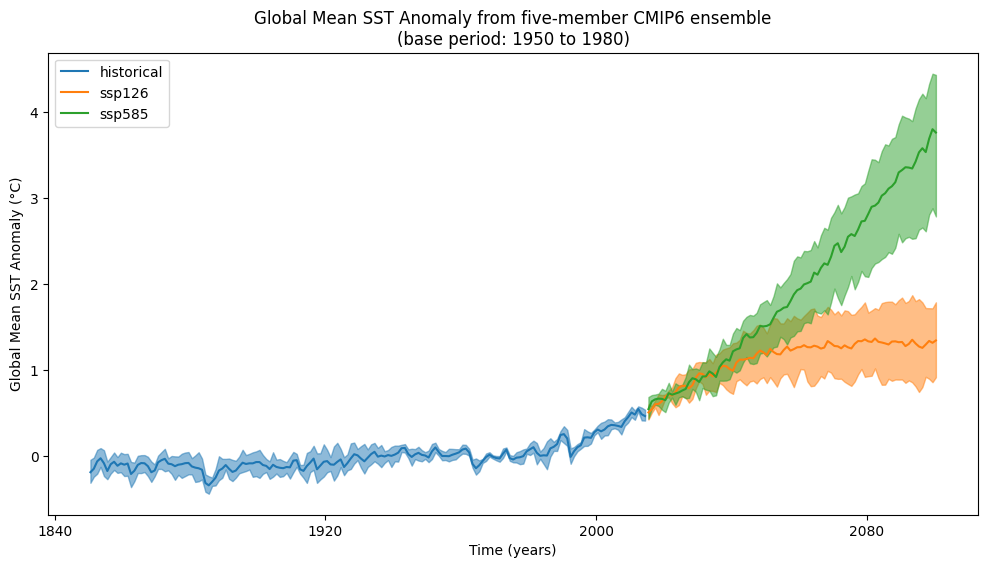

In [77]:
%%time
#################################################
## TODO for students: Plot range of global mean SST anomaly for five-member ensemble##
#################################################

fig, ax = plt.subplots(figsize=(12,6))
for experiment, color in zip(["historical", "ssp126", "ssp585"], ["C0", "C1", "C2"]):
    datasets = []
    for model in dt_gm_anomaly.keys():
        # calculate annual mean
        annual_sst = (
            dt_gm_anomaly[model][experiment]
            .ds.tos.coarsen(time=12)
            .mean()
            .assign_coords(source_id=model)
        )
        datasets.append(
            annual_sst.sel(time=slice(None, "2100")).load()
        )  # the french model has a long running member for ssp126
    # concatenate all along source_id dimension
    da = xr.concat(datasets, dim="source_id", join="override").squeeze()
    # compute ensemble mean and draw time series
    da.mean(dim="source_id").plot(color=color, label=experiment, ax=ax)
    # extract time coordinates
    x = da.time.data
    # Calculate the lower bound of the likely range
    da_lower = da.squeeze().quantile(0.17, dim="source_id")
    # Calculate the upper bound of the likely range
    da_upper = da.squeeze().quantile(0.83, dim="source_id")
    # shade via quantile boundaries
    ax.fill_between(x, da_lower, da_upper, alpha=0.5, color=color)

# aesthetics
ax.set_title(
    "Global Mean SST Anomaly from five-member CMIP6 ensemble\n(base period: 1950 to 1980)"
)
ax.set_ylabel("Global Mean SST Anomaly (°C)")
ax.set_xlabel("Time (years)")
ax.legend()

### Produces a VERY IPCC looking plot! The model uncertainty is higher for the SSP8.5 scenario but the temp anomaly is also higher. Using the middle 66% of the model results means that for five models we throw out the lowest and highest anomaly model projection

## Tutorial 4: Synthesizing & Interpreting diverse data sources <br><br>

#### In this tutorial, we will synthesize scientific knowledge from various sources and use this diverse information to validate and contextualize CMIP6 simulations. By the end of this tutorial, you will be able to

- Create a time series of global mean sea surface temperature from observations, models, and proxy data;

- Use this data to validate and contextualize climate models, as well as to provide a holistic picture of Earth’s past and future climate evolution.

In [78]:
col = intake.open_esm_datastore(
    "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
)  # open an intake catalog containing the Pangeo CMIP cloud data

# pick our five example models
# there are many more to test out! Try executing `col.df['source_id'].unique()` to get a list of all available models
source_ids = ["IPSL-CM6A-LR", "GFDL-ESM4", "ACCESS-CM2", "MPI-ESM1-2-LR", "TaiESM1"]
experiment_ids = ["historical", "ssp126", "ssp585"]

# from the full `col` object, create a subset using facet search
cat = col.search(
    source_id=source_ids,
    variable_id="tos",
    member_id="r1i1p1f1",
    table_id="Omon",
    grid_label="gn",
    experiment_id=experiment_ids,
    require_all_on=[
        "source_id"
    ],  # make sure that we only get models which have all of the above experiments
)

# convert the sub-catalog into a datatree object, by opening each dataset into an xarray.Dataset (without loading the data)
kwargs = dict(
    preprocess=combined_preprocessing,  # apply xMIP fixes to each dataset
    xarray_open_kwargs=dict(
        use_cftime=True
    ),  # ensure all datasets use the same time index
    storage_options={
        "token": "anon"
    },  # anonymous/public authentication to google cloud storage
)

cat.esmcat.aggregation_control.groupby_attrs = ["source_id", "experiment_id"]
dt = cat.to_datatree(**kwargs)

cat_area = col.search(
    source_id=source_ids,
    variable_id="areacello",  # for the coding exercise, ellipses will go after the equals on this line
    member_id="r1i1p1f1",
    table_id="Ofx",  # for the coding exercise, ellipses will go after the equals on this line
    grid_label="gn",
    experiment_id=[
        "historical"
    ],  # for the coding exercise, ellipses will go after the equals on this line
    require_all_on=["source_id"],
)

cat_area.esmcat.aggregation_control.groupby_attrs = ["source_id", "experiment_id"]
dt_area = cat_area.to_datatree(**kwargs)

dt_with_area = DataTree()

for model, subtree in dt.items():
    metric = dt_area[model]["historical"].ds["areacello"]
    dt_with_area[model] = subtree.map_over_subtree(_parse_metric, metric)

# average every dataset in the tree globally
dt_gm = dt_with_area.map_over_subtree(global_mean)

dt_gm_anomaly = datatree_anomaly(dt_gm)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_id/experiment_id'



--> The keys in the returned dictionary of datasets are constructed as follows:
	'source_id/experiment_id'


#### Complete the following code to:

- Calculate a time series of the global mean sea surface temperature (GMSST) from the HadISST dataset

- Subtract a base period from the HadISST GMSST time series. Use the same base period as the CMIP6 time series you are comparing against.

CPU times: user 1min 24s, sys: 33.8 s, total: 1min 57s
Wall time: 4min 35s


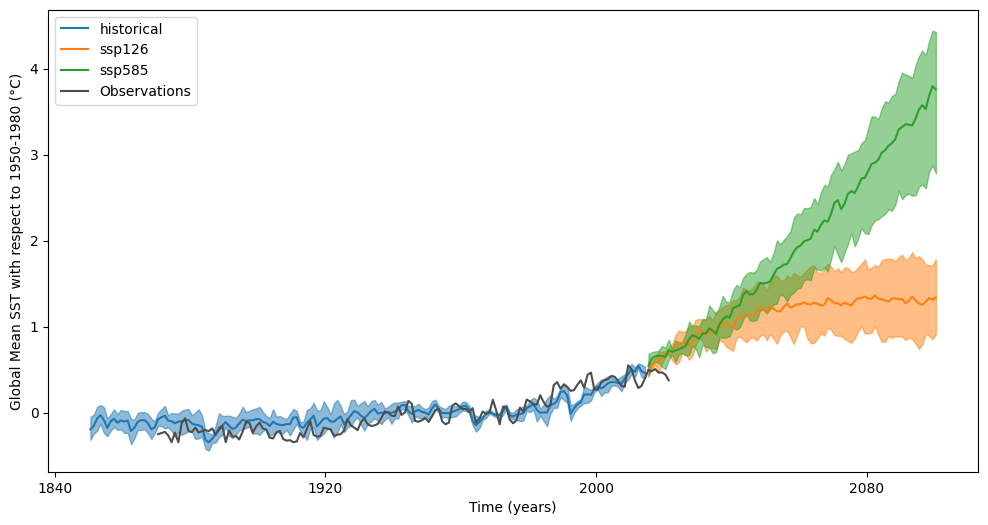

In [82]:
%%time
#################################################
## TODO for students: Add HadISST (observation-based) dataset to the previous CMIP ensemble plot. ##
#################################################

fig, ax = plt.subplots(figsize=(12,6))
for experiment, color in zip(["historical", "ssp126", "ssp585"], ["C0", "C1", "C2"]):
    datasets = []
    for model in dt_gm_anomaly.keys():
        # calculate annual mean
        annual_sst = (
            dt_gm_anomaly[model][experiment]
            .ds.tos.coarsen(time=12)
            .mean()
            .assign_coords(source_id=model)
            .load()
        )
        datasets.append(
            annual_sst.sel(time=slice(None, "2100")).load()
        )  # the french model has a long running member for ssp 126
    # concatenate all along source_id dimension
    da = xr.concat(datasets, dim="source_id", join="override").squeeze()
    # compute ensemble mean and draw time series
    da.mean("source_id").plot(color=color, label=experiment, ax=ax)
    # extract time coordinates
    x = da.time.data
    # calculate the lower and upper bound of the likely range
    da_lower = da.squeeze().quantile(0.17, dim="source_id")
    da_upper = da.squeeze().quantile(0.83, dim="source_id")
    # shade via quantile boundaries
    ax.fill_between(x, da_lower, da_upper, alpha=0.5, color=color)


# but now add observations (https://pangeo-forge.org/dashboard/feedstock/43)
store = "https://ncsa.osn.xsede.org/Pangeo/pangeo-forge/HadISST-feedstock/hadisst.zarr"
ds_obs = xr.open_dataset(store, engine="zarr", chunks={}).convert_calendar(
    "standard", use_cftime=True
)
# mask missing values
ds_obs = ds_obs.where(ds_obs > -1000)
weights = np.cos(
    np.deg2rad(ds_obs.latitude)
)  # In a regular lon/lat grid, area is ~cos(latitude)
# calculate weighted global mean for observations
sst_obs_gm = ds_obs.sst.weighted(weights).mean(["latitude", "longitude"])
# calculate anomaly for observations relative to global mean SST from 1950-1980
sst_obs_gm_anomaly = sst_obs_gm - sst_obs_gm.sel(time=slice("1950","1980")).mean()

# make it annual instead of monthly
sst_obs_gm_anomaly.coarsen(time=12, boundary="trim").mean().plot(
    color="0.3", label="Observations", ax=ax
)
ax.set_ylabel("Global Mean SST with respect to 1950-1980 (°C)")
ax.set_xlabel("Time (years)")
ax.legend()

#### the models do a pretty decent job of matching the HadISST observational data <br>

## <br> W2D3 Socioeconomics of climate change <br><br>

### Tutorial 1: Using the En-ROADS simulator, I was able to get a combo of actions & policies to limit warming to 1.9$^\circ$C : https://en-roads.climateinteractive.org/scenario.html?v=24.5.0&p1=100&p7=85&p10=5&p16=-0.03&p39=97&p47=3.7&p50=1.6&p373=20&p375=21&p63=9.9&p235=1.1&p60=29&p417=27&p61=26&p57=-2.7&g0=2&g1=62 <br><br>

### Tutorial 4: Shared socioeconomic pathways <br>

In [11]:
# imports
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pooch
import os
import tempfile
from scipy import integrate
from scipy import stats

In [2]:
# @title Helper functions

def pooch_load(filelocation=None, filename=None, processor=None):
    shared_location = "/home/jovyan/shared/Data/tutorials/W2D3_FutureClimate-IPCCII&IIISocio-EconomicBasis"  # this is different for each day
    user_temp_cache = tempfile.gettempdir()

    if os.path.exists(os.path.join(shared_location, filename)):
        file = os.path.join(shared_location, filename)
    else:
        file = pooch.retrieve(
            filelocation,
            known_hash=None,
            fname=os.path.join(user_temp_cache, filename),
            processor=processor,
        )

    return file


def legend_without_duplicate_labels(ax):
    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique))

#### investigating some IAM model output. The simulations are labeled by both the Shared Socioeconomic Pathway (SSP1, SSP2, SSP3, SSP4, and SSP5) and the forcing level (greenhouse gas forcing of 2.6, 7.0, 8.5 W/m2 etc. by 2100). The 5 SSPS are:

- SSP1: Sustainability (Taking the Green Road)
- SSP2: Middle of the Road
- SSP3: Regional Rivalry (A Rocky Road)
- SSP4: Inequality (A Road divided)
- SSP5: Fossil-fueled Development (Taking the Highway)
<br>
We select two SSPs to exemplify how these scenarios differ from each other. To get a strong contrast, we select SSP1 and SSP5.

Let’s load the data and describe their features along a few plots.

Like in other tutorials, we provide a .csv file that is stored in the cloud and was downloaded beforehand from this IIASA database, where all data from the main simulations of the IAMs used in the IPCC reports is freely available.

In [85]:
# Load SSP data from .csv file
filename_SSPs = 'SSP_IAM_V2_201811.csv'
link_id = "2uwr4"
url_SSPs = f"https://osf.io/download/{link_id}/"

df = pd.read_csv(pooch_load(url_SSPs, filename_SSPs))
# get a summary of the resulting pandas dataframe
df.info()

SHA256 hash of downloaded file: ec5b7bb804e49cf964d1028a7450cce96e6dd25f1ac9381326b2309063a93909
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84353 entries, 0 to 84352
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MODEL     84353 non-null  object 
 1   SCENARIO  84353 non-null  object 
 2   REGION    84353 non-null  object 
 3   VARIABLE  84353 non-null  object 
 4   UNIT      84353 non-null  object 
 5   2005      67962 non-null  float64
 6   2010      83666 non-null  float64
 7   2020      84227 non-null  float64
 8   2030      84227 non-null  float64
 9   2040      84227 non-null  float64
 10  2050      84224 non-null  float64
 11  2060      84224 non-null  float64
 12  2070      84224 non-null  float64
 13  2080      84215 non-null  float64
 14  2090      84215 non-null  float64
 15  2100      84215 non-null  float64
dtypes: float64(11), object(5)
memory usage: 10.3+ MB


In [88]:
#df
print(df.SCENARIO.unique())      # print all scenarios
print(df.VARIABLE.unique()[:10]) # print the first 10 variables
print(df.REGION.unique())        # print all regions
print(df.MODEL.unique())         # print all IAMs
print(df.UNIT.unique())          # print all units

['SSP1-19' 'SSP1-26' 'SSP1-34' 'SSP1-45' 'SSP1-Baseline' 'SSP2-19'
 'SSP2-26' 'SSP2-34' 'SSP2-45' 'SSP2-60' 'SSP2-Baseline' 'SSP3-34'
 'SSP3-45' 'SSP3-60' 'SSP3-Baseline' 'SSP4-26' 'SSP4-34' 'SSP4-45'
 'SSP4-Baseline' 'SSP5-26' 'SSP5-34' 'SSP5-45' 'SSP5-60' 'SSP5-Baseline'
 'SSP4-60' 'SSP5-19' 'SSP1-60' 'SSP4-19']
['Agricultural Demand|Crops' 'Agricultural Demand|Crops|Energy'
 'Agricultural Demand|Livestock' 'Agricultural Production|Crops|Energy'
 'Agricultural Production|Crops|Non-Energy'
 'Agricultural Production|Livestock' 'Capacity|Electricity'
 'Capacity|Electricity|Biomass' 'Capacity|Electricity|Coal'
 'Capacity|Electricity|Gas']
['R5.2ASIA' 'R5.2LAM' 'R5.2MAF' 'R5.2OECD' 'R5.2REF' 'World']
['AIM/CGE' 'GCAM4' 'IMAGE' 'MESSAGE-GLOBIOM' 'REMIND-MAGPIE'
 'WITCH-GLOBIOM']
['million t DM/yr' 'GW' 'billion US$2005/yr' 'Mt BC/yr' 'Mt CH4/yr'
 'Mt CO/yr' 'Mt CO2/yr' 'Mt CO2-equiv/yr' 'kt N2O/yr' 'Mt NH3/yr'
 'Mt NO2/yr' 'Mt OC/yr' 'Mt SO2/yr' 'Mt VOC/yr' 'EJ/yr' 'million ha'
 'million' 

#### Helper function to filter the full data set

In [90]:
# @markdown *Execute this cell to enable the dataframe filter function: `get_SSPs_for_variable`*

def get_SSPs_for_variable(df,scenario,variable,region='World'):
    '''

    Function that filters IIASA's SSP database that is stored in a data frame 'df'
    and was loaded before from the 'SSP_IAM_V2_201811.csv' file.
    It returns a data frame with selected columns depending on scenario, variable and region input.
    For a given SSP scenario it chooses the conventional model for the respective scenario
    (cf. https://tntcat.iiasa.ac.at/SspDb/dsd?Action=htmlpage&page=about#v2).

    Args:
        scenario: string in "SSPX-XX" with X=1,...,5
        variable: string in df.VARIABLE, e.g. 'Population' or 'GDP|PPP'

    Returns:
        SSP data for selected columns for a given SSP scenario

    Example:
        dd = get_SSPs_for_variable(df,'SSP1-26','Population')

    '''
    ssp_model_conv = {"SSP1-Baseline" : "IMAGE",
                      "SSP1-26" : "IMAGE",
                      "SSP2-Baseline" : "MESSAGE-GLOBIOM",
                      "SSP3-Baseline" : "AIM/CGE",
                      "SSP4-Baseline" : "GCAM4",
                      "SSP5-Baseline" : "REMIND-MAGPIE"}
    model = ssp_model_conv[scenario]
    ds = df.query(f'(VARIABLE == "{variable}") & (SCENARIO == "{scenario}")  & (MODEL == "{model}") & (REGION == "{region}")')
    return ds

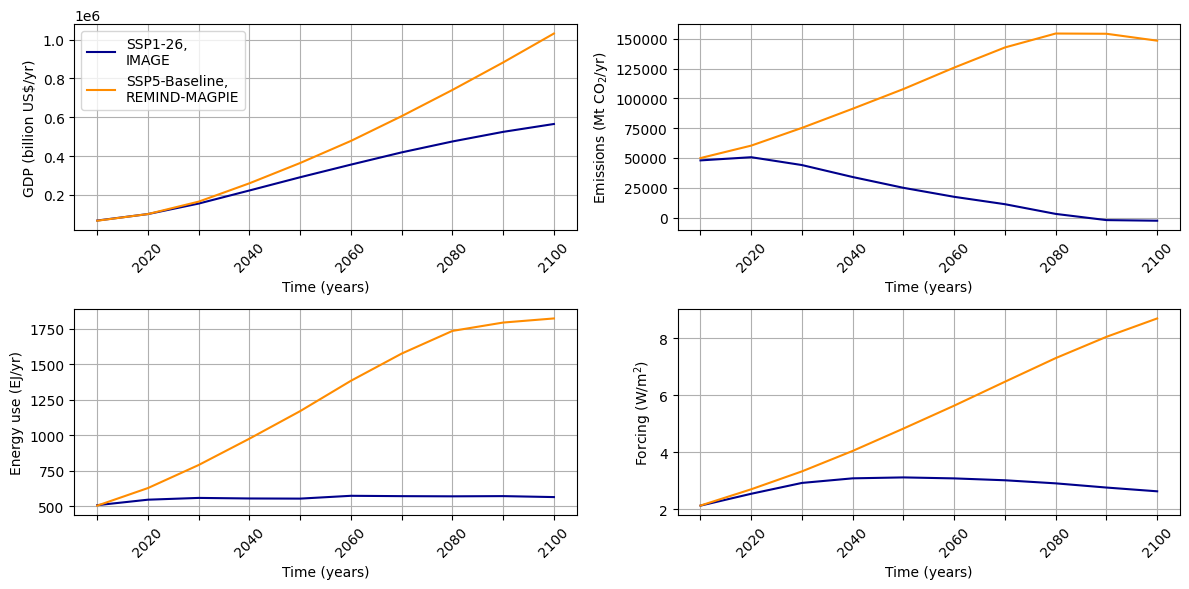

In [97]:
# put variables of interest in a list
vars = ['GDP|PPP','Emissions|Kyoto Gases', 'Primary Energy','Diagnostics|MAGICC6|Forcing']
# create new names for structured data series and axes labels
val_name = ['GDP (billion US$/yr)', 'Emissions (Mt CO$_2$/yr)',  'Energy use (EJ/yr)', 'Forcing (W/m$^2$)']
# choose scenarios of interest and a color for plotting
scenarios = ['SSP1-26', 'SSP5-Baseline']
colors = ['darkblue','darkorange']

# init figure and axis
fig, axs = plt.subplots(figsize=(12,6),nrows=2,ncols=2)
# loop over all variables and new names
for var, val, ax in zip(vars,val_name, axs.flatten()):

    # loop over scenarios and their color
    for sc, col in zip(scenarios, colors):
        # retrieve SSP for the respective variable from rich data frame
        ds_unstrct = get_SSPs_for_variable(df,sc,var)
        # restructure dataframe for plotting
        ds_strct = pd.melt(ds_unstrct, id_vars=["MODEL"], value_vars=['2010','2020','2030','2040','2050','2060','2070','2080','2090','2100'], var_name="YEAR", value_name =val)
        #print(ds_strct)
        # plot variable vs. time, add label incl. scenario and model
        ax.plot(ds_strct['YEAR'],ds_strct[val],label=f'{sc},\n{ds_strct.MODEL[0]}', color=col)
        # altern. plotting procedure w/o the color distinction
        #sns.lineplot(ds_strct, x='YEAR', y=val, hue='MODEL', ax=ax, palette='flare')

    # aesthetics
    ax.set_ylabel(fr'{val}')
    ax.set_xlabel('Time (years)')
    plt.setp(ax.get_xticklabels(), rotation=45)
    plt.setp(ax.get_xticklabels()[::2], visible=False)
    ax.grid(True)
    axs[0,0].legend()
    plt.tight_layout()

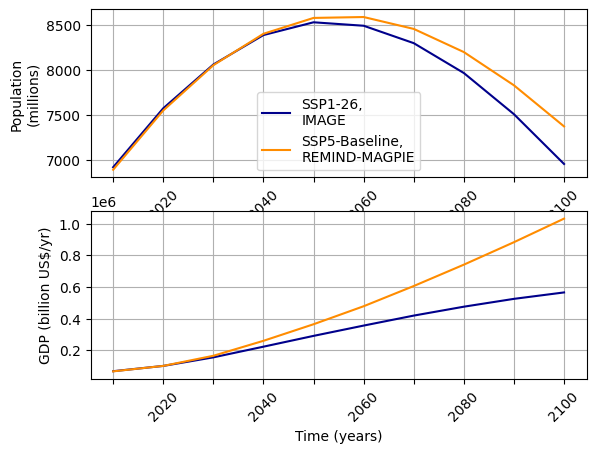

In [98]:
# put variables of interest in a list
vars = ['Population', 'GDP|PPP']
# create new names for structured data series and plot labels
val_name = ['Population\n(millions)', 'GDP (billion US$/yr)']
# choose scenarios of interest and a color for plotting
scenarios = ['SSP1-26', 'SSP5-Baseline']
colors = ['darkblue','darkorange']

# init figure and axis
fig, axs = plt.subplots(2,1)
# loop over all variables and new names
for var, val, ax in zip(vars,val_name, axs.flatten()):

    # loop over scenarios and their color
    for sc, col in zip(scenarios, colors):
        # retrieve SSP for the respective variable from rich dataframe
        ds_unstrct = get_SSPs_for_variable(df,sc,var)
        # restructure dataframe for plotting
        ds_strct = pd.melt(ds_unstrct, id_vars=["MODEL"], value_vars=['2010','2020','2030','2040','2050','2060','2070','2080','2090','2100'], var_name="YEAR", value_name =val)
        #print(ds_strct)
        # plot variable vs. time, add label incl. scenario and model
        ax.plot(ds_strct['YEAR'],ds_strct[val],label=f'{sc},\n{ds_strct.MODEL[0]}', color=col)
        # altern. plotting procedure w/o the color distinction
        #sns.lineplot(ds_strct, x='YEAR', y=val, hue='MODEL', ax=ax, palette='flare')

    # aesthetics
    ax.set_ylabel(fr'{val}')
    ax.set_xlabel('Time (years)')
    plt.setp(ax.get_xticklabels(), rotation=45)
    plt.setp(ax.get_xticklabels()[::2], visible=False)
    ax.grid(True)
    axs[0].legend()

#### Coding exercise 1.3
- Choose two variables to emphasize ecosystem health differences in the SSP1 and SSP5 scenarios and assign them to vars. Then assign axis labels with the correct units for plotting to the val_name variable.
- Explain to your pod why the chosen variables emphasize a difference in the scenarios and describe this difference based on your current knowledge of the narratives.

In [102]:
print(df.VARIABLE.unique())#[:30])

['Agricultural Demand|Crops' 'Agricultural Demand|Crops|Energy'
 'Agricultural Demand|Livestock' 'Agricultural Production|Crops|Energy'
 'Agricultural Production|Crops|Non-Energy'
 'Agricultural Production|Livestock' 'Capacity|Electricity'
 'Capacity|Electricity|Biomass' 'Capacity|Electricity|Coal'
 'Capacity|Electricity|Gas' 'Capacity|Electricity|Geothermal'
 'Capacity|Electricity|Hydro' 'Capacity|Electricity|Nuclear'
 'Capacity|Electricity|Oil' 'Capacity|Electricity|Solar'
 'Capacity|Electricity|Solar|PV' 'Capacity|Electricity|Wind'
 'Capacity|Electricity|Wind|Onshore' 'Consumption' 'Emissions|BC'
 'Emissions|CH4' 'Emissions|CH4|Land Use' 'Emissions|CO' 'Emissions|CO2'
 'Emissions|CO2|Carbon Capture and Storage'
 'Emissions|CO2|Carbon Capture and Storage|Biomass'
 'Emissions|CO2|Fossil Fuels and Industry' 'Emissions|CO2|Land Use'
 'Emissions|F-Gases' 'Emissions|Kyoto Gases' 'Emissions|N2O'
 'Emissions|N2O|Land Use' 'Emissions|NH3' 'Emissions|NOx' 'Emissions|OC'
 'Emissions|Sulfur' 'E

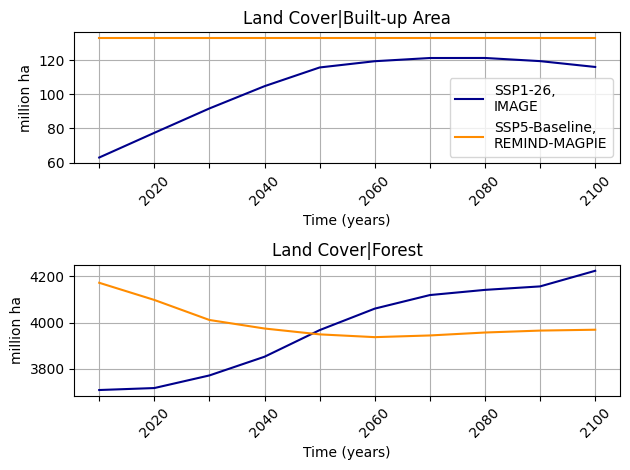

In [109]:
# put two variables of interest in a list
vars = ['Land Cover|Built-up Area', 'Land Cover|Forest']
# create new names for structured data series and plot labels
val_name = ['million ha','million ha','million ha','million ha']
# choose scenarios of interest and a color for plotting
scenarios = ['SSP1-26', 'SSP5-Baseline']
colors = ['darkblue','darkorange']

#################################################
## TODO for students:
## Put two variables of interest in a list and assign it to 'vars'.
## Create new names for the structured data series and axes labels,
## put them in a list and assign it to 'val_name'.
#################################################

# init figure and axis
fig, axs = plt.subplots(2,1)
# loop over all variables and new names
for var, val, ax in zip(vars,val_name, axs.flatten()):

    # loop over scenarios and their color
    for sc, col in zip(scenarios, colors):
        # retrieve SSP for the respective variable from rich dataframe
        ds_unstrct = get_SSPs_for_variable(df,sc,var)
        # restructure dataframe for plotting
        ds_strct = pd.melt(ds_unstrct, id_vars=["MODEL"], value_vars=['2010','2020','2030','2040','2050','2060','2070','2080','2090','2100'], var_name="YEAR", value_name =val)
        #print(ds_strct)
        # plot variable vs. time, add label incl. scenario and model
        ax.plot(ds_strct['YEAR'],ds_strct[val],label=f'{sc},\n{ds_strct.MODEL[0]}', color=col)
        ax.set_title(fr'{var}')
        # altern. plotting procedure w/o the color distinction
        #sns.lineplot(ds_strct, x='YEAR', y=val, hue='MODEL', ax=ax, palette='flare')

    # aesthetics
    ax.set_ylabel(fr'{val}')
    ax.set_xlabel('Time (years)')
    
    plt.setp(ax.get_xticklabels(), rotation=45)
    plt.setp(ax.get_xticklabels()[::2], visible=False)
    ax.grid(True)
    axs[0].legend()
    plt.tight_layout()

## <br> W2D4 Tutorial 1: Distributions <br>

### statistically analyzing a dataset of annual maximum daily precipitation records for Germany.

In [3]:
# download file: 'precipitationGermany_1920-2022.csv'
filename_precipitationGermany = "precipitationGermany_1920-2022.csv"
url_precipitationGermany = "https://osf.io/xs7h6/download"
data = pd.read_csv(
    pooch_load(url_precipitationGermany, filename_precipitationGermany), index_col=0
).set_index("years")
data.columns = ["precipitation"]
precipitation = data.precipitation

SHA256 hash of downloaded file: ef9f29e709a1db0745c28bcb9460dac22f6c9624de41d9e2187ab547e9aaa3c8
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


In [4]:
precipitation

years
1920    24.5
1921    27.7
1922    15.6
1923    23.5
1924    59.9
        ... 
2018    31.6
2019    24.9
2020    33.3
2021    57.4
2022    25.4
Name: precipitation, Length: 103, dtype: float64

### amount of precipitation that was observed at a point in Germany at 51 N 6 E.

<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_74042/1752089717.py:4: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Germany @ 51$^\circ$N, 6$^\circ$E")


Text(0.5, 1.0, 'Germany @ 51$^\\circ$N, 6$^\\circ$E')

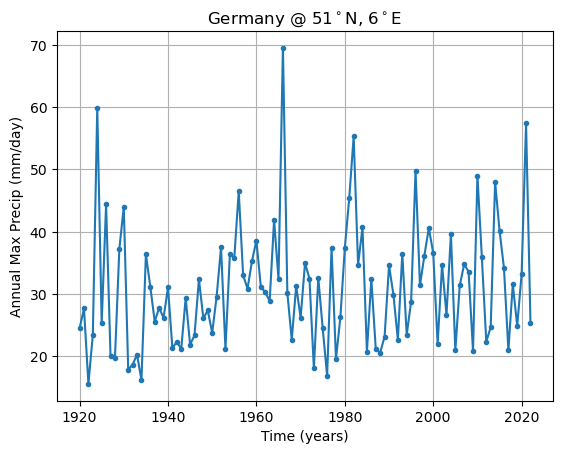

In [5]:
precipitation.plot.line(style=".-", grid=True)
plt.xlabel("Time (years)")
plt.ylabel("Annual Max Precip (mm/day)")
plt.title("Germany @ 51$^\circ$N, 6$^\circ$E")

Text(0.5, 0, 'Annual Max Precip (mm/day)')

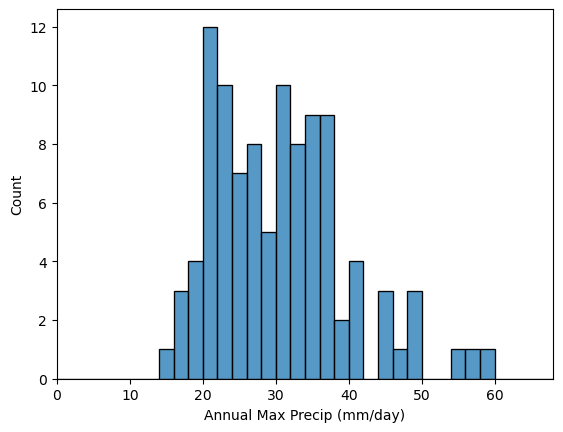

In [6]:
# make a histogram using seaborn
fig,ax = plt.subplots()

# create bins
bins = np.arange(0, precipitation.max(), 2)

sns.histplot(precipitation, bins = bins, ax=ax)

ax.set_xlim(bins[0], bins[-1])
ax.set_xlabel("Annual Max Precip (mm/day)")

### looks kinda normal but with a bit more tail on the right (skewed to the right) <br> <br> Compute mean, variance, std dev

In [7]:
mean_pr = precipitation.mean()
var_pr = precipitation.var()
std_pr = precipitation.std()

mean_pr, var_pr, std_pr

(30.97184466019418, 98.55047401484865, 9.92725913910021)

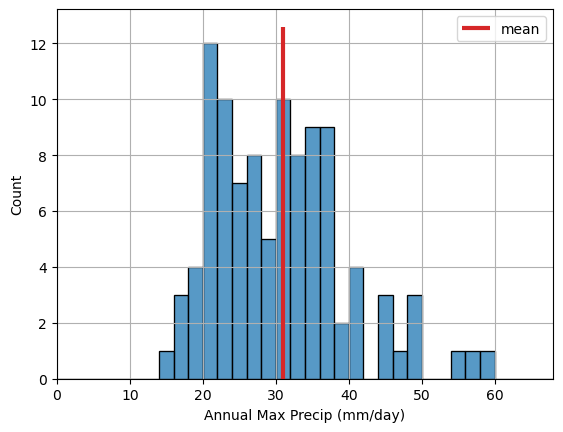

In [8]:
# update plot
# make a histogram using seaborn
fig,ax = plt.subplots()

# create bins
bins = np.arange(0, precipitation.max(), 2)

sns.histplot(precipitation, bins = bins, ax=ax)
ax.set_xlim(bins[0], bins[-1])

ylim = ax.get_ylim()

# add vertical line for mean
ax.vlines(mean_pr, ymin = ylim[0], ymax=ylim[1], color="C3", lw=3, label='mean')

ax.set_xlabel("Annual Max Precip (mm/day)")
ax.grid()
ax.legend()

### find the skew - it indicates skewed to the right (> 0)

In [9]:
precipitation.skew()

1.1484425874858337

In [12]:
# make normal data to assess skew
normal_data = np.random.normal(0,1, size=data.index.size)

# check skew of normal dist (should be near zero)
stats.skew(normal_data)

0.11887321479564529

### add a PDF to histogram

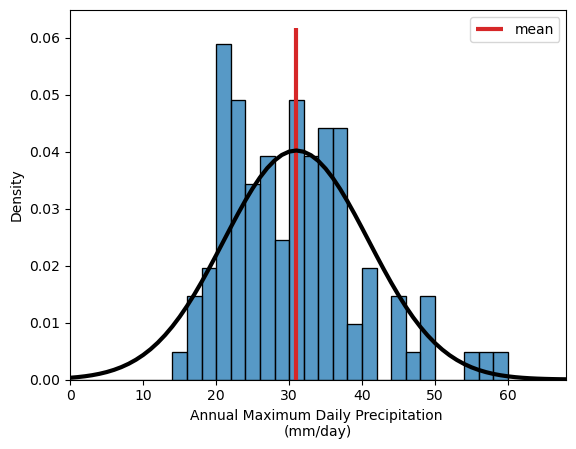

In [13]:
fig, ax = plt.subplots()
bins = np.arange(0, precipitation.max(), 2)
sns.histplot(
    precipitation, bins=bins, ax=ax, stat="density"
)  # notice the different stat being ploted
ax.set_xlim(bins[0], bins[-1])

ylim = ax.get_ylim()

# add in vertical line at mean
ax.vlines(mean_pr, ymin=ylim[0], ymax=ylim[1], color="C3", lw=3, label="mean")

# add PDF
x_r100 = np.arange(0, 100, 1)
ax.plot(x_r100, stats.norm.pdf(x_r100, mean_pr, std_pr), c="k", lw=3)

ax.set_xlabel("Annual Maximum Daily Precipitation \n(mm/day)")
ax.legend()

### Add uncertainty bands to the distribution.

1. Create 1000 records of 100 samples each that are drawn from a normal distribution with the mean and standard deviation of the precipitation record.

2. Compute the 5-th and 95-th percentiles across the 1000-member ensemble and add them to the figure above to get an idea of the uncertainty.

In [126]:
#help(np.random.normal)

Text(0.5, 1.0, 'Comparison of precip data to normal dist, \n5th & 95th percentiles shown')

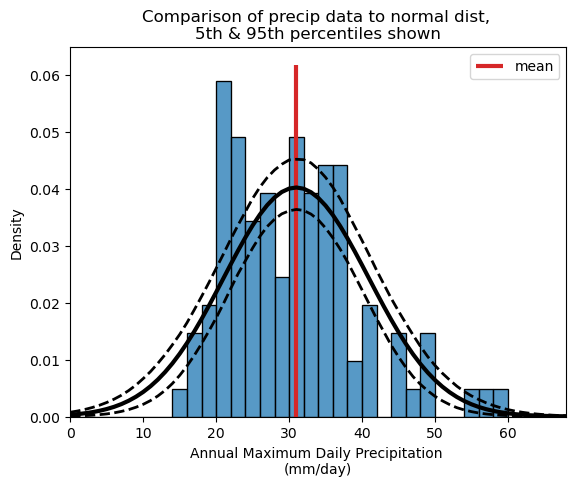

In [14]:
# take 1000 records of 100 samples
random_samples = np.random.normal(loc=mean_pr, scale=std_pr, size=[100,1000])

# create placeholder for pdfs
pdfs = np.zeros([x_r100.size, 1000])

# loop through all 1000 records and create a pdf of each sample
for i in range(1000):
    # find pdfs
    pdfi = stats.norm.pdf(x_r100, 
                          random_samples[:,i].mean(), 
                          random_samples[:,i].std())

    # add to array
    pdfs[:,i] = pdfi


# make plot
fig, ax = plt.subplots()

# create histogram again
bins = np.arange(0, precipitation.max(), 2)
sns.histplot(
    precipitation, bins=bins, ax=ax, stat="density"
)  # notice the different stat being ploted
ax.set_xlim(bins[0], bins[-1])

ylim = ax.get_ylim()

# add in vertical line at mean
ax.vlines(mean_pr, ymin=ylim[0], ymax=ylim[1], color="C3", lw=3, label="mean")

# plot pdf
_ = ax.plot(x_r100, stats.norm.pdf(x_r100, mean_pr, std_pr), c="k", lw=3)

# plot 95th percentile
_ = ax.plot(x_r100, np.quantile(pdfs, 0.95, axis=1), ls="--", lw=2, color='k')

# plot 5th percentile
_ = ax.plot(x_r100, np.quantile(pdfs, 0.05, axis=1), ls="--", lw=2, color='k')

# set xlabel
ax.set_xlabel("Annual Maximum Daily Precipitation \n(mm/day)")
ax.legend()
ax.set_title("Comparison of precip data to normal dist, \n5th & 95th percentiles shown")

### <br> Seems safe to conclude that the precip data doesn't match a normal distribution. Tutorial suggests maybe lognorm is better for this shape? <br>

## <br>Tutorial 2: extreme events: empirical return levels <br>

In [15]:
# precipitation record from Germany

# download file: 'precipitationGermany_1920-2022.csv'
filename_precipitationGermany = "precipitationGermany_1920-2022.csv"
url_precipitationGermany = "https://osf.io/xs7h6/download"
data = pd.read_csv(
    pooch_load(url_precipitationGermany, filename_precipitationGermany), index_col=0
).set_index("years")
data.columns = ["precipitation"]
precipitation = data.precipitation
precipitation

years
1920    24.5
1921    27.7
1922    15.6
1923    23.5
1924    59.9
        ... 
2018    31.6
2019    24.9
2020    33.3
2021    57.4
2022    25.4
Name: precipitation, Length: 103, dtype: float64

<Axes: xlabel='Time (years)', ylabel='Annual max daily precip \n(mm/day)'>

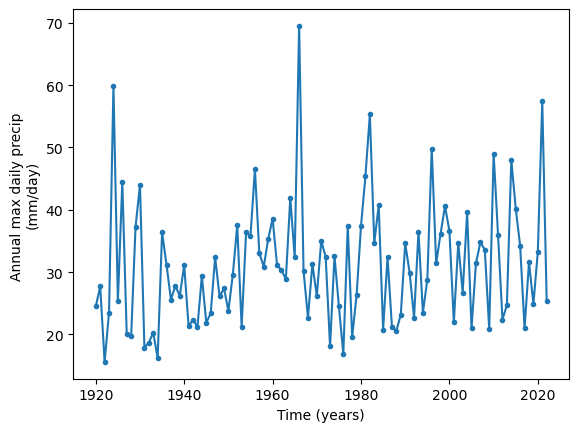

In [16]:
# make a plot
precipitation.plot.line(
    style=".-",
    xlabel="Time (years)",
    ylabel="Annual max daily precip \n(mm/day)"
)


#### In this tutorial, we will calculate the return period for each event in the dataset, specifically for each maximum precipitation value recorded in a given year. To accomplish this, we will begin by ranking the precipitation levels in descending order using the sort function. The sorted data will be saved in the first column of a matrix named “precip” with four columns, and the number of rows will correspond to the number of data entries. <br> <br>In the second column of the matrix, we will store the ranks assigned to each precipitation value, with the highest value assigned a rank of 1 and the lowest value assigned a rank corresponding to the total number of entries (e.g., 103).



In [17]:
# create inital data frame from precip data
precip_df = pd.DataFrame(index=np.arange(data.precipitation.size))
precip_df

""
0
1
2
3
4
...
98
99
100
101


In [18]:
# sort it
precip_df["sorted"] = np.sort(data.precipitation)[::-1] #the indexing thing on the end reverses the sort order!
#precip_df

# assign ranks ignoring duplicate values
precip_df["rank"] = np.arange(data.precipitation.size) # same as index + 1

In [162]:
len(precip_df)

103

In [19]:
# how many unique values tho?
len(np.unique(precip_df["sorted"]))

87

In [20]:
# 16 duplicates in there to deal with and get ranks tied for those?
# use rankdata function from scipy which handles the dupe ranks by assigning the same rank
precip_df["ranks_sp"] = np.sort(stats.rankdata(-data.precipitation)) # the "-" reverses the order?
len(np.unique(precip_df["ranks_sp"]))

87

In [21]:
# can see how it handles the tie values
precip_df.ranks_sp[12:28]

12    13.0
13    14.0
14    15.0
15    16.0
16    17.0
17    18.0
18    19.5
19    19.5
20    21.0
21    22.0
22    23.0
23    24.5
24    24.5
25    26.0
26    27.0
27    28.0
Name: ranks_sp, dtype: float64

In [22]:
# empirical prob of exceedence by dividin rank (r) by total amount of values (n) + 1
n = data.precipitation.size
precip_df["exceedence"] = precip_df["ranks_sp"] / (n + 1)

# return period and chance of exceedence are related thru T = 1/P

# find return period
precip_df["period"] = 1 / precip_df["exceedence"]

# see it
precip_df

,sorted,rank,ranks_sp,exceedence,period
0,69.5,0,1.0,0.009615,104.000000
1,59.9,1,2.0,0.019231,52.000000
2,57.4,2,3.0,0.028846,34.666667
3,55.3,3,4.0,0.038462,26.000000
4,49.8,4,5.0,0.048077,20.800000
...,...,...,...,...,...
98,18.1,98,99.0,0.951923,1.050505
99,17.9,99,100.0,0.961538,1.040000
100,16.9,100,101.0,0.971154,1.029703
101,16.2,101,102.0,0.980769,1.019608


### plot the exceedence probability


Text(0.5, 1.0, 'Return Periods for Precip in Germany')

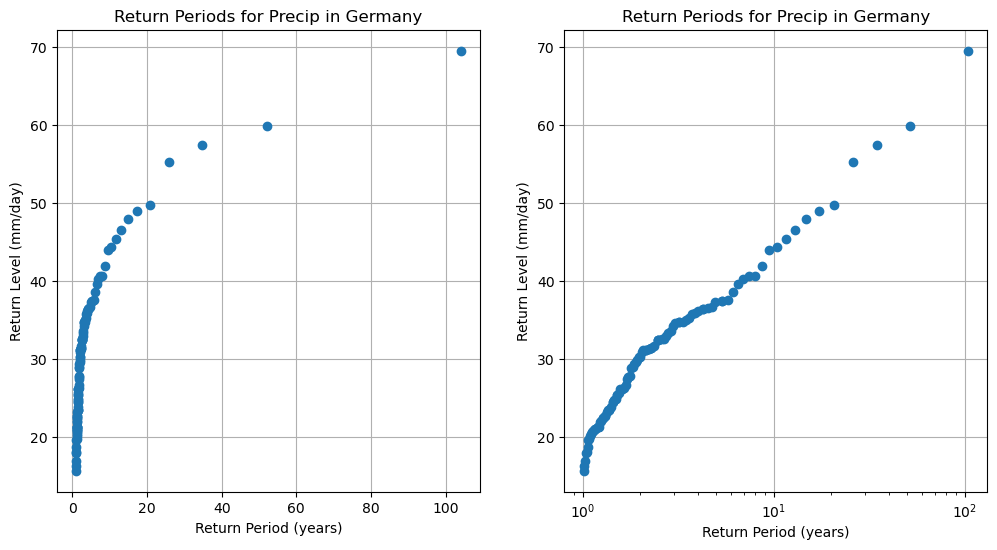

In [23]:
fig,(ax1, ax2) = plt.subplots(ncols=2, figsize=(12,6))
ax1.plot(precip_df["period"], precip_df["sorted"], "o")
ax1.grid(True)
ax1.set_xlabel("Return Period (years)")
ax1.set_ylabel("Return Level (mm/day)")
ax1.set_xscale("linear") # note this scale
ax1.set_title("Return Periods for Precip in Germany")

ax2.plot(precip_df["period"], precip_df["sorted"], "o")
ax2.grid(True)
ax2.set_xlabel("Return Period (years)")
ax2.set_ylabel("Return Level (mm/day)")
ax2.set_xscale("log") # note this scale
ax2.set_title("Return Periods for Precip in Germany")


# fig, ([ax_regridded, ax_native]) = plt.subplots(
#     ncols=2, figsize=[12, 3], subplot_kw={"projection": ccrs.Robinson()}
# )

### Coding exercise - bootstrapping to give us more data and estimate uncertainty

1. We pull artificial observations from our data - with replacement.

2. We draw as many observations as our data record is long. This record will now only include data points that we observed before, but some will show up several times, some not at all.

3. We compute our statistics over this artifical record - just as we did to the record itself.

4. We repeat this process many times.

5. Thus we compute our statistics over many artificial records, which can give us an indication of the uncertainty.

Remember, this only works under the assumption that our data is representative of the process - that we did not systematically miss something about the data. We cannot use this to estimate how hot it could get during noon if we only recorded the temperature at night.

In this exercise, you may now:

Define a function to calculate the empirical return period, then take 1000 resamples with replacement (each value could be sampled more than once) and plot the associated return level curves for each sample, together with the return period of the original data set.

Text(0.5, 1.0, 'Return Periods for Precip in Germany')

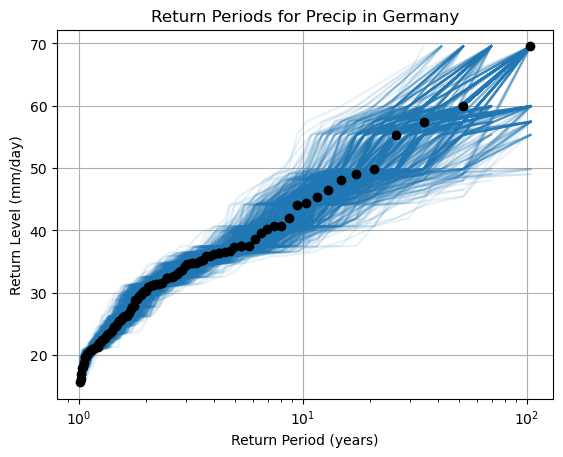

In [24]:
# define a function to calculate the empirical return period by using the code from the cells above.
# add period and sorted to a dataframe as before
def empirical_period(data):
    n = data.size
    df = pd.DataFrame(index=np.arange(n))
    df["sorted"] = np.sort(data)[::-1]
    df["ranks_sp"] = np.sort(stats.rankdata(-data))
    df["exceedance"] = df["ranks_sp"] / (n + 1)
    df["period"] = 1 / df["exceedance"]
    return df[["period", "sorted"]].set_index("period")["sorted"]


# setup figure
fix, ax = plt.subplots()

# create 1000 resamples of the data, with replacement set to true.
for i in range(1000):
    empirical_period(
        #select random sample with replacement and plot it
        np.random.choice(data.precipitation.values, # which values to draw from
                         size = data.precipitation.size, # how many to draw
                         replace=True
                        )
    ).plot(style = "C0-", alpha=0.1, ax=ax)

# aesthetics
ax.plot(precip_df["period"], precip_df["sorted"], "ko")
ax.grid(True)
ax.set_xlabel("Return Period (years)")
ax.set_ylabel("Return Level (mm/day)")
ax.set_xscale("log")
ax.set_title("Return Periods for Precip in Germany")

### Note that uncertainty gets larger as we get to higher return periods (there's less data out there)